# 4. Modélisation supervisée et semi-supervisée

Objectif : comparer un modèle entraîné uniquement sur les données fortement labellisées avec un modèle semi-supervisé utilisant aussi des pseudo-labels issus du clustering.

On va comparer :
- Modèle supervisé baseline = entraîné uniquement sur les 100 images fortement labellisées
- Modèle semi-supervisé = entraîné sur les labels forts + pseudo-labels issus du clustering KMeans

Et surtout : le test set doit venir uniquement des labels forts, jamais des pseudo-labels.

In [21]:
# Imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

In [22]:
# Charger les résultats de clustering
DATA_PATH = Path("data/processed/clustering_results.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(1506, 525)


,path,label,split,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,...,cluster_kmeans,cluster_dbscan,PC1,PC2,PC3,TSNE1,TSNE2,TSNE1_3D,TSNE2_3D,TSNE3_3D
0,data\raw\avec_labels\cancer\05340cd4-3bb2-459d...,cancer,avec_labels,0.223682,0.710136,1.481257,0.459431,0.692085,0.185364,2.059628,...,0,0,8.396483,-2.436171,7.176140,42.510120,-29.786404,21.015488,-17.777609,1.802920
1,data\raw\avec_labels\cancer\0c6f3641-60d9-4a76...,cancer,avec_labels,2.303200,1.045277,1.294456,2.547840,0.545068,0.133437,1.212342,...,1,1,-8.551546,-4.022785,-2.804376,-9.233247,15.479722,-2.821812,6.201744,7.743300
2,data\raw\avec_labels\cancer\0f718241-8f63-4b55...,cancer,avec_labels,3.997212,1.404900,1.149433,0.966352,1.491258,0.024406,1.677062,...,1,1,-6.108632,-2.111135,-3.556742,-3.443153,20.144793,1.201895,10.207444,9.279955
3,data\raw\avec_labels\cancer\11a7a426-4806-401e...,cancer,avec_labels,2.034307,1.851072,1.561280,0.760116,0.673758,0.079369,3.240707,...,2,-1,-1.963537,6.659886,-0.570339,-19.801159,31.811998,-6.846777,16.701790,-8.202891
4,data\raw\avec_labels\cancer\1c043dbb-4623-4769...,cancer,avec_labels,2.823692,1.664199,1.330548,1.195984,2.489143,0.071206,2.423799,...,2,-1,6.257315,14.876310,-4.353542,-1.743610,36.785706,8.053403,20.339365,4.648187


In [23]:
# Identifier les colonnes
feature_columns = [col for col in df.columns if col.startswith("feature_")]

print("Nombre de features :", len(feature_columns))
print("Labels disponibles :")
display(df["label"].value_counts())

print("Clusters KMeans :")
display(df["cluster_kmeans"].value_counts())

Nombre de features : 512
Labels disponibles :


label
unknown    1406
cancer       50
normal       50
Name: count, dtype: int64

Clusters KMeans :


cluster_kmeans
0    672
1    645
2    189
Name: count, dtype: int64

In [24]:
# Séparer données fortes et unknown
strong_df = df[df["label"].isin(["normal", "cancer"])].copy()
unknown_df = df[df["label"] == "unknown"].copy()

print("Données fortement labellisées :", strong_df.shape)
display(strong_df["label"].value_counts())

print("Données non labellisées :", unknown_df.shape)

Données fortement labellisées : (100, 525)


label
cancer    50
normal    50
Name: count, dtype: int64

Données non labellisées : (1406, 525)


In [25]:
# Split train/test stratifié sur les données fortement labellisées
train_idx, test_idx = train_test_split(
    strong_df.index,
    test_size=0.30,
    random_state=42,
    stratify=strong_df["label"]
)

train_strong_df = df.loc[train_idx].copy()
test_strong_df = df.loc[test_idx].copy()

X_train_strong = train_strong_df[feature_columns].values
y_train_strong = train_strong_df["label"].values

X_test = test_strong_df[feature_columns].values
y_test = test_strong_df["label"].values

print("Train fort :", X_train_strong.shape)
print("Test :", X_test.shape)

print("Distribution train :")
display(pd.Series(y_train_strong).value_counts())

print("Distribution test :")
display(pd.Series(y_test).value_counts())

Train fort : (70, 512)
Test : (30, 512)
Distribution train :


normal    35
cancer    35
Name: count, dtype: int64

Distribution test :


cancer    15
normal    15
Name: count, dtype: int64

In [26]:
# Fonction d’évaluation
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro"),
        "recall_macro": recall_score(y_test, y_pred, average="macro"),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "f1_cancer": f1_score(y_test, y_pred, pos_label="cancer")
    }

    print(model_name)
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=["normal", "cancer"])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["normal", "cancer"],
        yticklabels=["normal", "cancer"]
    )
    plt.title(f"Matrice de confusion - {model_name}")
    plt.xlabel("Prédiction")
    plt.ylabel("Label réel")
    plt.show()

    return metrics

Supervisé - labels forts uniquement
              precision    recall  f1-score   support

      cancer       0.87      0.87      0.87        15
      normal       0.87      0.87      0.87        15

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30



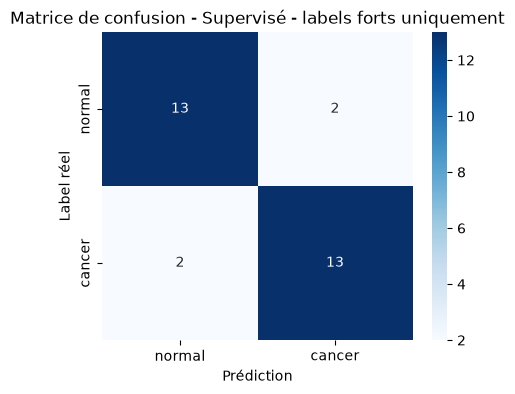

{'model': 'Supervisé - labels forts uniquement',
 'accuracy': 0.8666666666666667,
 'precision_macro': 0.8666666666666667,
 'recall_macro': 0.8666666666666667,
 'f1_macro': 0.8666666666666667,
 'f1_cancer': 0.8666666666666667}

In [27]:
# Modèle supervisé baseline
supervised_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

supervised_model.fit(X_train_strong, y_train_strong)

supervised_metrics = evaluate_model(
    supervised_model,
    X_test,
    y_test,
    "Supervisé - labels forts uniquement"
)

supervised_metrics

In [28]:
# Associer chaque cluster KMeans à un label majoritaire
# on associe chaque cluster KMeans à son label majoritaire, en utilisant seulement les labels forts du train.
cluster_label_table = pd.crosstab(
    train_strong_df["cluster_kmeans"],
    train_strong_df["label"]
)

display(cluster_label_table)

cluster_to_label = cluster_label_table.idxmax(axis=1).to_dict()

cluster_to_label

label,cancer,normal
cluster_kmeans,,
0,21,2
1,8,33
2,6,0


{0: 'cancer', 1: 'normal', 2: 'cancer'}

In [29]:
# Pseudo-labelliser uniquement les unknown
unknown_df["pseudo_label"] = unknown_df["cluster_kmeans"].map(cluster_to_label)

display(unknown_df["pseudo_label"].value_counts(dropna=False))

pseudo_label
cancer    821
normal    585
Name: count, dtype: int64

In [30]:
# Garder seulement les pseudo-labels exploitables
pseudo_labeled_df = unknown_df.dropna(subset=["pseudo_label"]).copy()

print("Pseudo-labels conservés :", pseudo_labeled_df.shape)
display(pseudo_labeled_df["pseudo_label"].value_counts())

Pseudo-labels conservés : (1406, 526)


pseudo_label
cancer    821
normal    585
Name: count, dtype: int64

In [31]:
# Construire le train semi-supervisé
train_strong_for_semi = train_strong_df.copy()
train_strong_for_semi["training_label"] = train_strong_for_semi["label"]

pseudo_labeled_for_semi = pseudo_labeled_df.copy()
pseudo_labeled_for_semi["training_label"] = pseudo_labeled_for_semi["pseudo_label"]

semi_train_df = pd.concat(
    [train_strong_for_semi, pseudo_labeled_for_semi],
    axis=0
)

X_train_semi = semi_train_df[feature_columns].values
y_train_semi = semi_train_df["training_label"].values

print("Train semi-supervisé :", X_train_semi.shape)
display(pd.Series(y_train_semi).value_counts())

Train semi-supervisé : (1476, 512)


cancer    856
normal    620
Name: count, dtype: int64

In [32]:
# Vérifier la fuite de données entre le test et le train semi-supervisé (Résultat attendu : 0)
test_paths = set(test_strong_df["path"])
semi_train_paths = set(semi_train_df["path"])

leakage = test_paths.intersection(semi_train_paths)

print("Nombre d'images du test présentes dans le train semi-supervisé :", len(leakage))

Nombre d'images du test présentes dans le train semi-supervisé : 0


Semi-supervisé - labels forts + pseudo-labels KMeans
              precision    recall  f1-score   support

      cancer       1.00      0.73      0.85        15
      normal       0.79      1.00      0.88        15

    accuracy                           0.87        30
   macro avg       0.89      0.87      0.86        30
weighted avg       0.89      0.87      0.86        30



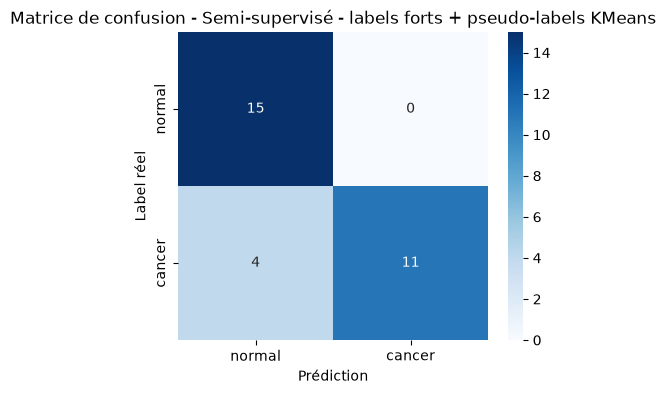

{'model': 'Semi-supervisé - labels forts + pseudo-labels KMeans',
 'accuracy': 0.8666666666666667,
 'precision_macro': 0.8947368421052632,
 'recall_macro': 0.8666666666666667,
 'f1_macro': 0.8642533936651584,
 'f1_cancer': 0.8461538461538461}

In [33]:
# Entraîner le modèle semi-supervisé
semi_supervised_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

semi_supervised_model.fit(X_train_semi, y_train_semi)

semi_supervised_metrics = evaluate_model(
    semi_supervised_model,
    X_test,
    y_test,
    "Semi-supervisé - labels forts + pseudo-labels KMeans"
)

semi_supervised_metrics

In [34]:
# Comparaison des performances
metrics_df = pd.DataFrame([
    supervised_metrics,
    semi_supervised_metrics
])

display(metrics_df)

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_cancer
0,Supervisé - labels forts uniquement,0.866667,0.866667,0.866667,0.866667,0.866667
1,Semi-supervisé - labels forts + pseudo-labels ...,0.866667,0.894737,0.866667,0.864253,0.846154


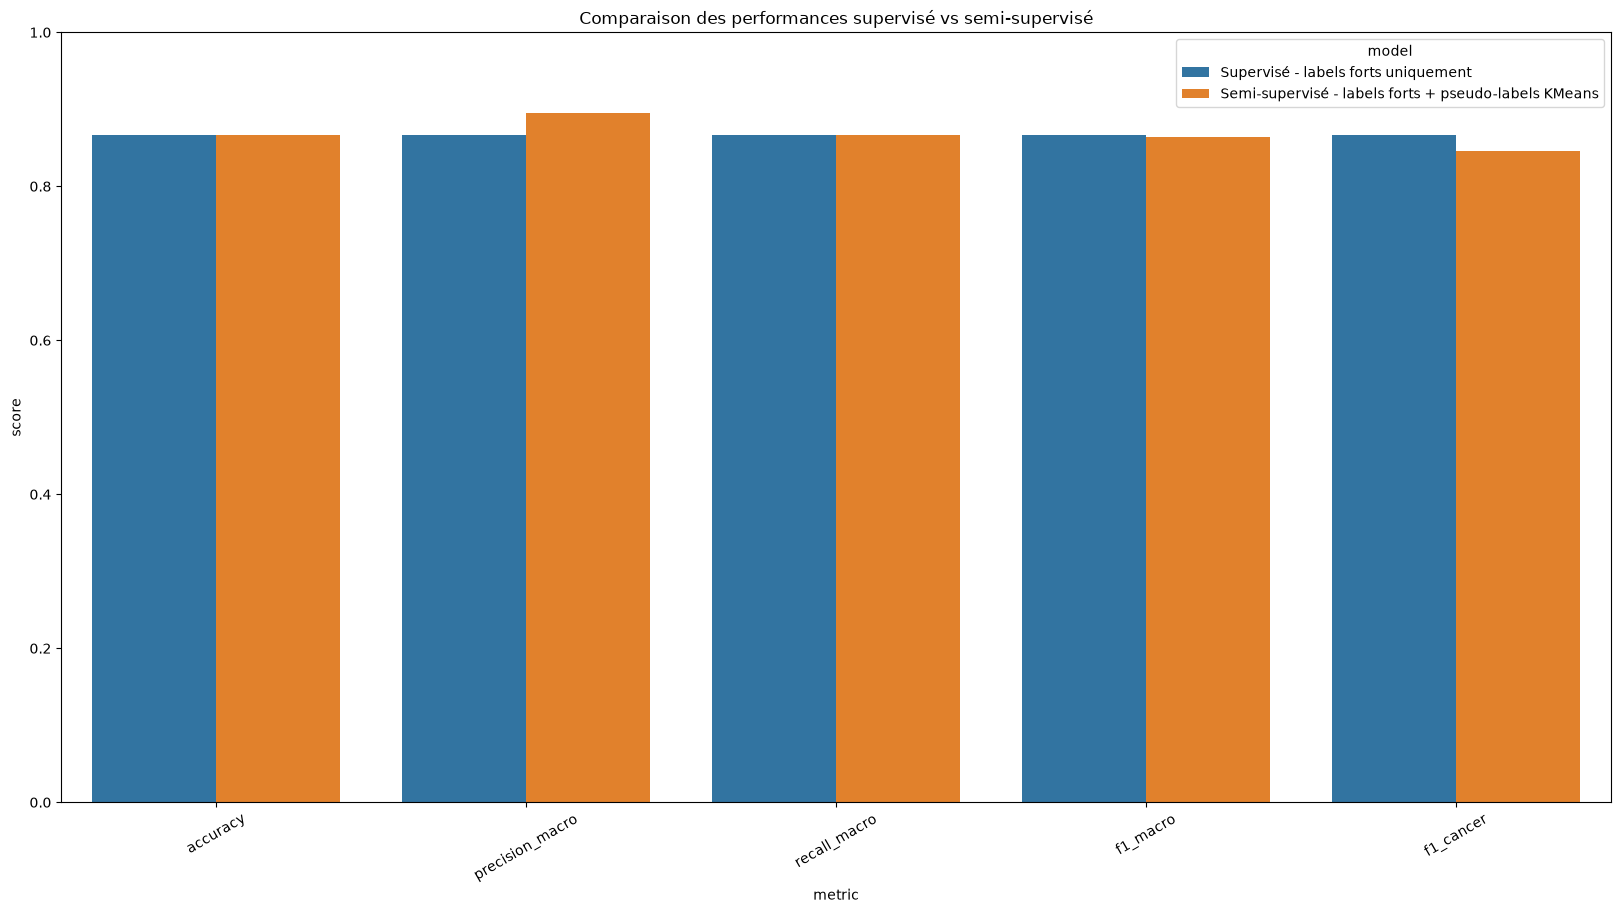

In [38]:
metrics_long = metrics_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_cancer"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(20, 10))
sns.barplot(
    data=metrics_long,
    x="metric",
    y="score",
    hue="model"
)
plt.ylim(0, 1)
plt.title("Comparaison des performances supervisé vs semi-supervisé")
plt.xticks(rotation=30)
plt.show()

La pseudo-labellisation augmente fortement la taille du jeu d'entraînement, de 70 images fortement labellisées à 1476 images au total. Cependant, les performances restent proches entre les deux modèles.

Cela suggère que les embeddings ResNet sont déjà fortement discriminants avec peu de labels, et que les pseudo-labels KMeans ajoutent surtout des exemples cohérents avec la frontière déjà apprise. Le gain mesurable reste limité, probablement aussi à cause de la petite taille du jeu de test.

## Interprétation

Le modèle supervisé est entraîné uniquement sur les images fortement labellisées présentes dans le train.

Le modèle semi-supervisé utilise les mêmes images fortement labellisées, auxquelles on ajoute les images initialement non labellisées. Ces images reçoivent un pseudo-label déterminé à partir du label majoritaire du cluster KMeans.

Les labels réels `normal` et `cancer` restent prioritaires : lorsqu'une image possède un label fort, ce label est utilisé et n'est jamais remplacé par un pseudo-label.

Le jeu de test est composé uniquement d'images fortement labellisées et n'est jamais utilisé pour créer les pseudo-labels. Cela limite le risque de fuite de données.

La métrique prioritaire est le F1-score de la classe `cancer`, car manquer une image cancéreuse est l'erreur la plus critique. Le F1 macro est également suivi pour évaluer l'équilibre global entre les classes.

In [40]:
# Sauvegarder les métriques et les pseudo-labels
OUTPUT_DIR = Path("data/processed")

metrics_path = OUTPUT_DIR / "modeling_metrics.csv"
pseudo_labels_path = OUTPUT_DIR / "pseudo_labels_kmeans.csv"
semi_train_path = OUTPUT_DIR / "semi_supervised_training_set.csv"

metrics_df.to_csv(metrics_path, index=False)
pseudo_labeled_df.to_csv(pseudo_labels_path, index=False)
semi_train_df.to_csv(semi_train_path, index=False)

print("Métriques sauvegardées :", metrics_path)
print("Pseudo-labels sauvegardés :", pseudo_labels_path)
print("Jeu d'entraînement semi-supervisé sauvegardé :", semi_train_path)

Métriques sauvegardées : data\processed\modeling_metrics.csv
Pseudo-labels sauvegardés : data\processed\pseudo_labels_kmeans.csv
Jeu d'entraînement semi-supervisé sauvegardé : data\processed\semi_supervised_training_set.csv


## Definition of Done - Étape 4

L'étape 4 est considérée comme terminée si :

- un split train/test stratifié est créé sur les données fortement labellisées ;
- le jeu de test n'est jamais utilisé pour générer les pseudo-labels ;
- un modèle supervisé est entraîné uniquement sur les labels forts ;
- les pseudo-labels sont générés uniquement pour les images `unknown` ;
- les labels forts ne sont jamais remplacés par des pseudo-labels ;
- un modèle semi-supervisé est entraîné sur labels forts + pseudo-labels ;
- les deux modèles sont évalués sur le même jeu de test ;
- les métriques accuracy, precision, recall et F1-score sont comparées ;
- la classe `cancer` est analysée en priorité ;
- les résultats sont sauvegardés.